## Ejercicios

### Kernel Identidad 3x3

In [130]:
# =====================================================================
# CLASE: Redes Convolucionales - Introducción a Kernels (Filtros)
# =====================================================================

# 1. Conectar Google Colab con Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Asegúrate de subir una imagen (por ejemplo, 'mi_imagen.jpg') a tu Drive.
# Modifica la siguiente ruta con la ubicación real de tu archivo en Drive.
ruta_imagen_drive = '/content/drive/MyDrive/B36D08BE-7451-4148-8CAD-075DCF5455B2.jpeg'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [131]:
# 2. Importar las librerías necesarias
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [132]:
try:
    # 3. Cargar la imagen desde Drive y convertirla a escala de grises
    # Nota didáctica: Usamos escala de grises (1 solo canal) para facilitar la comprensión matemática de la convolución.
    imagen_pil = Image.open(ruta_imagen_drive).convert('L')
    print("¡Imagen cargada correctamente desde Google Drive!")
except FileNotFoundError:
    print(f"Error: No se encontró ningún archivo en la ruta: {ruta_imagen_drive}")
    print("Por favor, verifica el nombre y la extensión del archivo en tu Google Drive.")
    

¡Imagen cargada correctamente desde Google Drive!


In [133]:
# 4. Preprocesamiento: Convertir la imagen en un Tensor de PyTorch
# Transformamos la imagen a un tensor con valores en el rango [0, 1]
transformacion = transforms.ToTensor()
imagen_tensor = transformacion(imagen_pil) # Dimensiones resultantes: [Canales, Alto, Ancho] -> [1, H, W]

# PyTorch requiere que el lote (batch) tenga la forma: [Batch_Size, Canales, Alto, Ancho]
imagen_tensor = imagen_tensor.unsqueeze(0) # Añadimos la dimensión del lote -> [1, 1, H, W]

In [134]:
# 5. Definición del Kernel de Identidad (3x3)
# Explicación: Matriz donde todos los elementos son 0 excepto el centro que es 1.
kernel_identidad = np.array([[0, 0, 0,],
                             [0, 1, 0],
                            [0, 0, 0]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [135]:
# 6. Aplicar la Operación de Convolución
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada = F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [136]:
# 7. Postprocesamiento: Remover las dimensiones extras para poder graficar
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
img_original_np = imagen_tensor.squeeze().numpy()
img_salida_np = imagen_convolucionada.squeeze().numpy()

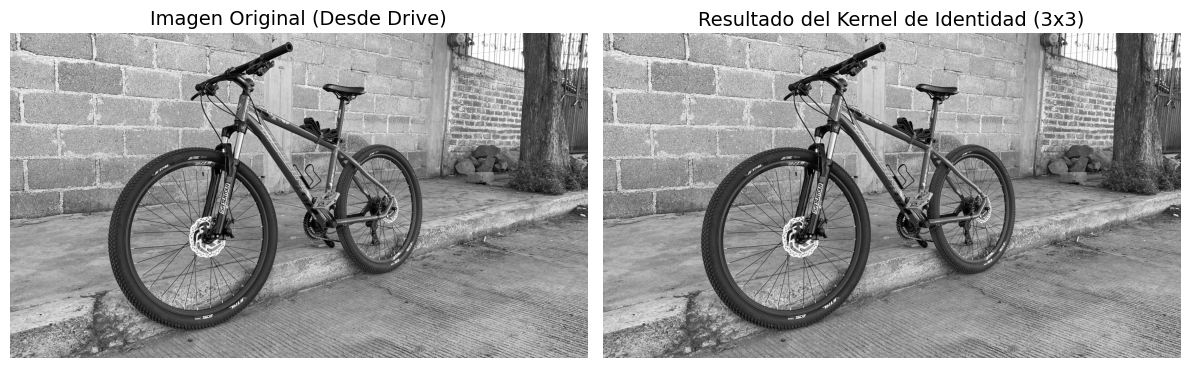

In [137]:
# 8. Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(img_salida_np, cmap='gray')
axes[1].set_title("Resultado del Kernel de Identidad (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Kernel 3x3 identidad  con valores de 50

In [138]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([[0, 0, 0],
                             [0, 50, 0],
                            [0, 0, 0]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [139]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_cincuenta = F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [140]:
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
img_salida_np_cincuenta = imagen_convolucionada_cincuenta.squeeze().numpy()

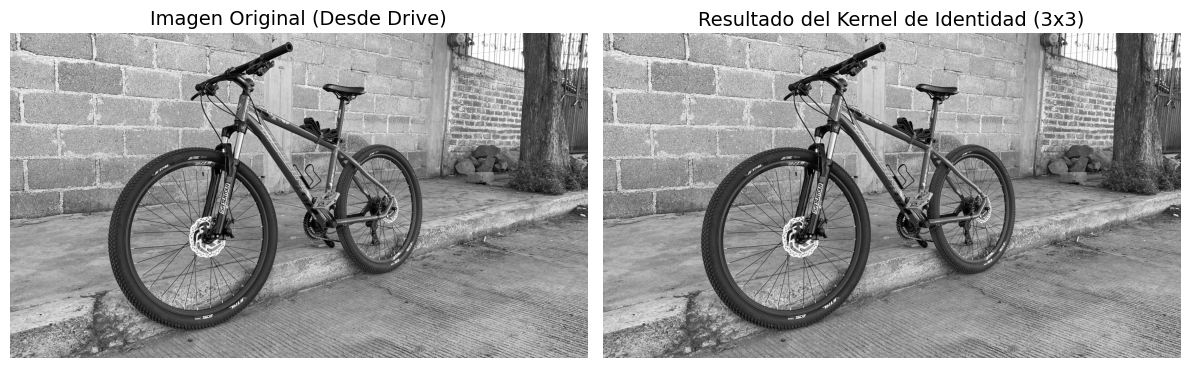

In [141]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(img_salida_np_cincuenta, cmap='gray')
axes[1].set_title("Resultado del Kernel de Identidad (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Kernel Detección de Bordes
#### Horizontal

In [142]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([[-1, -1, -1],
                             [0, 0, 0],
                            [1, 1, 1]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [143]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_horizontal = F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [144]:
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
imagen_convolucionada_horizontal = imagen_convolucionada_horizontal.squeeze().numpy()

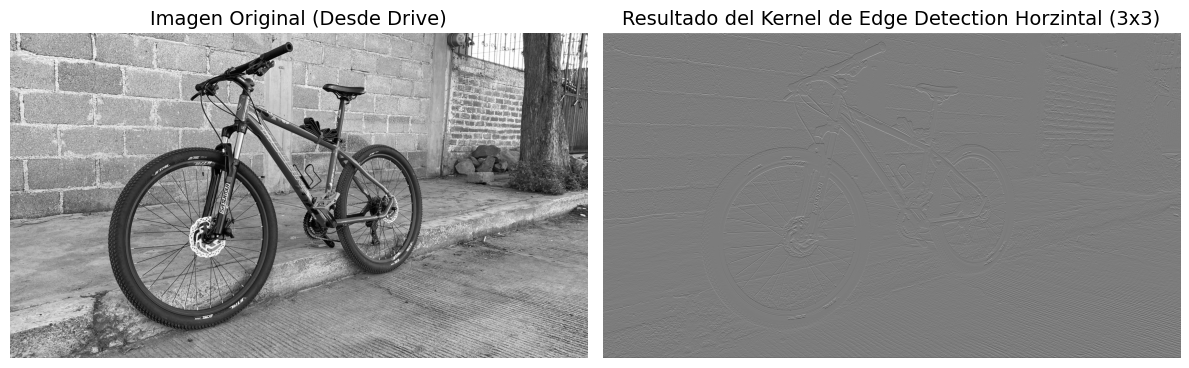

In [145]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(imagen_convolucionada_horizontal, cmap='gray')
axes[1].set_title("Resultado del Kernel de Edge Detection Horzintal (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### Edge Detection Vertical

In [146]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([[-1, 0, 1],
                             [-1, 0, 1],
                            [-1, 0, 1]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [147]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_vertical = F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [148]:
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
imagen_convolucionada_vertical = imagen_convolucionada_vertical.squeeze().numpy()

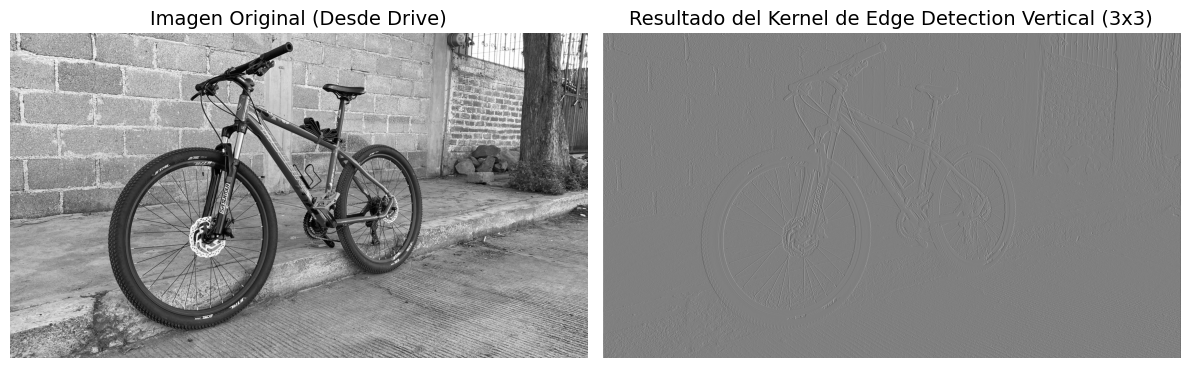

In [149]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(imagen_convolucionada_vertical, cmap='gray')
axes[1].set_title("Resultado del Kernel de Edge Detection Vertical (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Sharpening Kernel

In [150]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([   [0,     -1, 0],
                                [-1,    5,  -1],
                                [0,     -1,  0]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [151]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_sharpening = F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [152]:
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
imagen_convolucionada_sharpening = imagen_convolucionada_sharpening.squeeze().numpy()

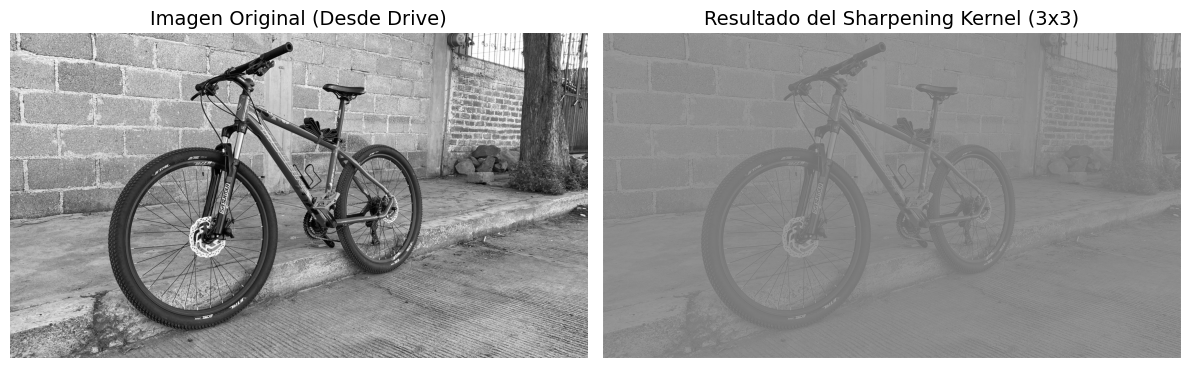

In [153]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(imagen_convolucionada_sharpening, cmap='gray')
axes[1].set_title("Resultado del Sharpening Kernel (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Box Blur Kernel

In [ ]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([   [(1/9),   (1/9),    (1/9)],
                                [(1/9),   (1/9),    (1/9)],
                                [(1/9),   (1/9),    (1/9)]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [163]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_boxblur = F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [164]:
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
imagen_convolucionada_boxblur = imagen_convolucionada_boxblur.squeeze().numpy()

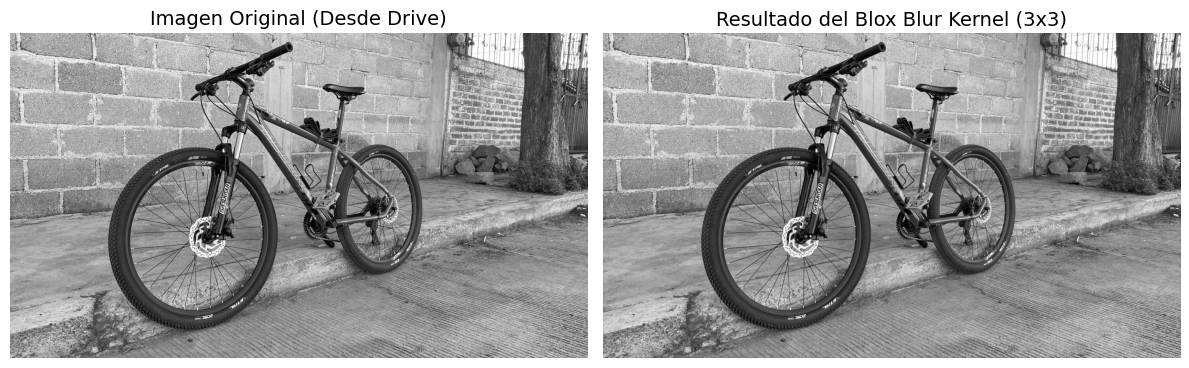

In [165]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(imagen_convolucionada_boxblur, cmap='gray')
axes[1].set_title("Resultado del Blox Blur Kernel (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Gaussian Blur Kernel

In [211]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([   [(1/16),   (2/16),    (1/16)],
                                [(2/16),   (4/16),    (2/16)],
                                [(1/16),   (2/16),    (1/16)]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [212]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_gaussianblur = F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [213]:
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
imagen_convolucionada_gaussianblur = imagen_convolucionada_gaussianblur.squeeze().numpy()

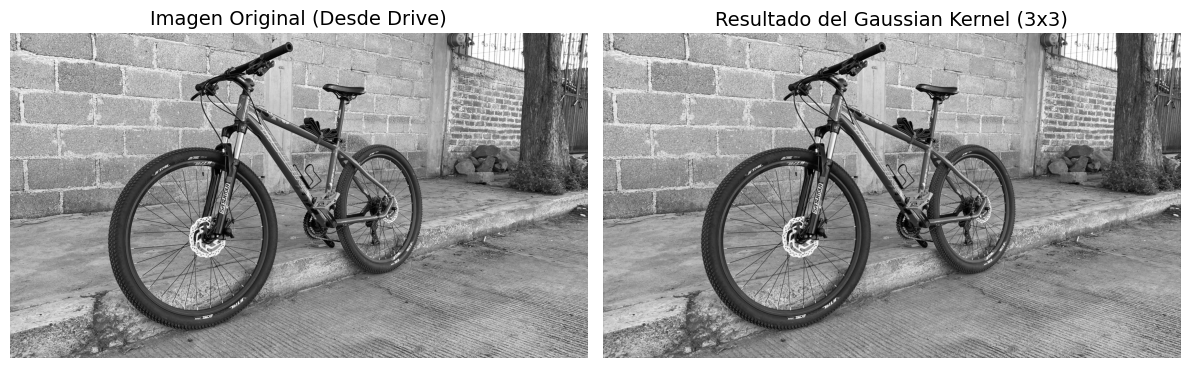

In [214]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(imagen_convolucionada_gaussianblur, cmap='gray')
axes[1].set_title("Resultado del Gaussian Kernel (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Sobel Kernels

#### Horizontal

In [172]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([   [-1,   0,     1],
                                [-2,   0,     2],
                                [-1,   0,     1]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [173]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_sobelhorizontal = F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [174]:
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
imagen_convolucionada_sobelhorizontal = imagen_convolucionada_sobelhorizontal.squeeze().numpy()

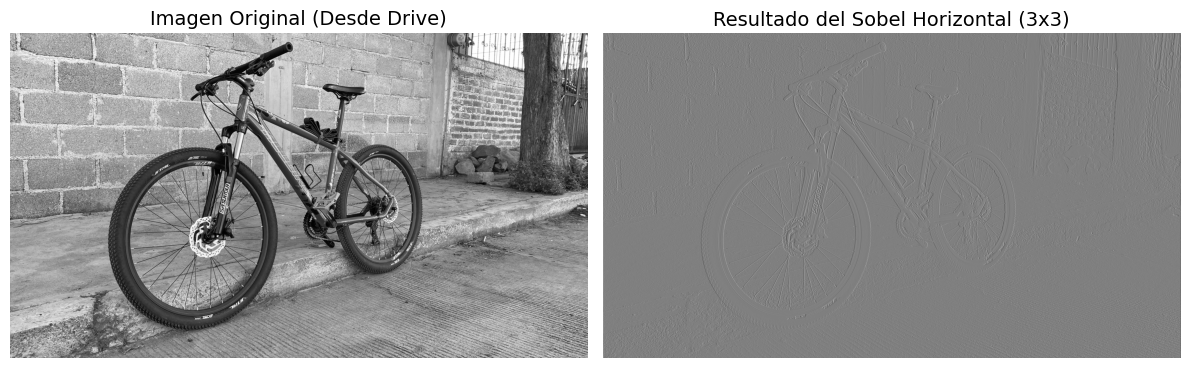

In [175]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(imagen_convolucionada_sobelhorizontal, cmap='gray')
axes[1].set_title("Resultado del Sobel Horizontal (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### Vertical


In [167]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([   [-1,   -2,    -1],
                                [ 0,   0,      0],
                                [ 1,   2,      1]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [168]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_sobelvertical = F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [169]:
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
imagen_convolucionada_sobelvertical = imagen_convolucionada_sobelvertical.squeeze().numpy()

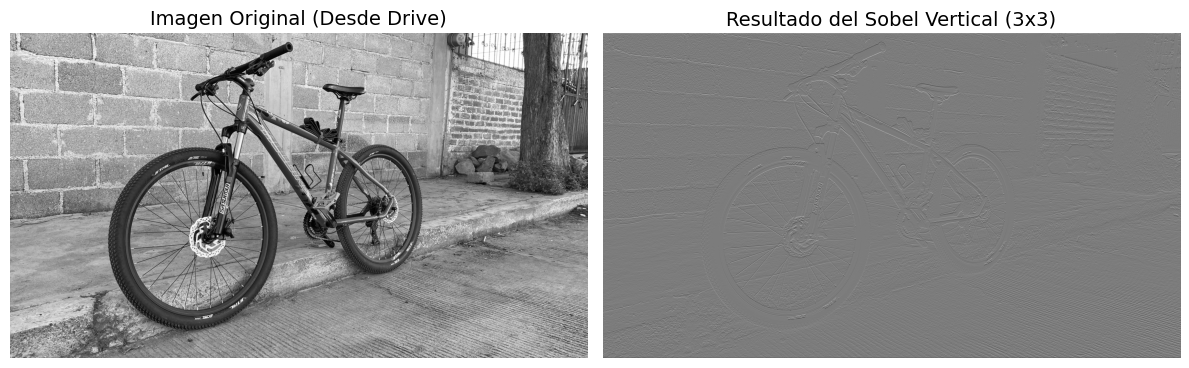

In [170]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(imagen_convolucionada_sobelvertical, cmap='gray')
axes[1].set_title("Resultado del Sobel Vertical (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Prewitt Kernels

#### Prewitt Horizontal

In [181]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([   [-1,   0,    1],
                                [-1,   0,    1],
                                [-1,   0,    1]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [182]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_prewittHorizontal= F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [183]:
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
imagen_convolucionada_prewittHorizontal = imagen_convolucionada_prewittHorizontal.squeeze().numpy()

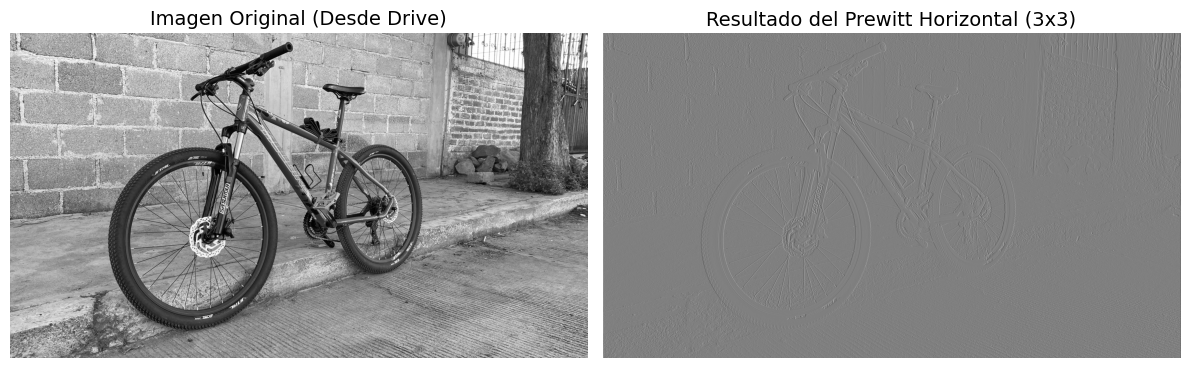

In [184]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(imagen_convolucionada_prewittHorizontal, cmap='gray')
axes[1].set_title("Resultado del Prewitt Horizontal (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### Prewit Vertical

In [185]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([   [-1,   -1,    -1],
                                [ 0,   0,      0],
                                [ 1,   1,      1]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [186]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_prewitvertical = F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [187]:
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
imagen_convolucionada_prewitvertical = imagen_convolucionada_prewitvertical.squeeze().numpy()

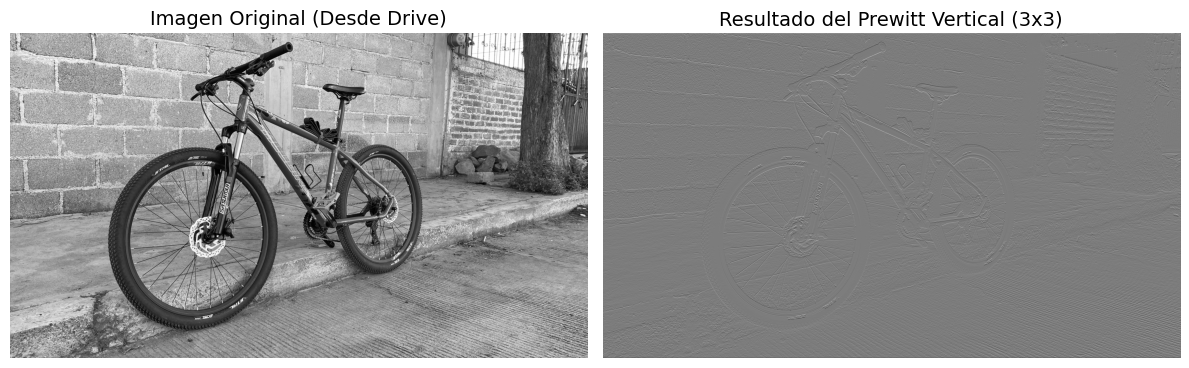

In [188]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(imagen_convolucionada_prewitvertical, cmap='gray')
axes[1].set_title("Resultado del Prewitt Vertical (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Laplacian Kernel

In [207]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([   [ 0,   -1,     0],
                                [-1,   4,     -1],
                                [ 0,   -1,      0]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [208]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_laplacian = F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [209]:
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
imagen_convolucionada_laplacian = imagen_convolucionada_laplacian.squeeze().numpy()

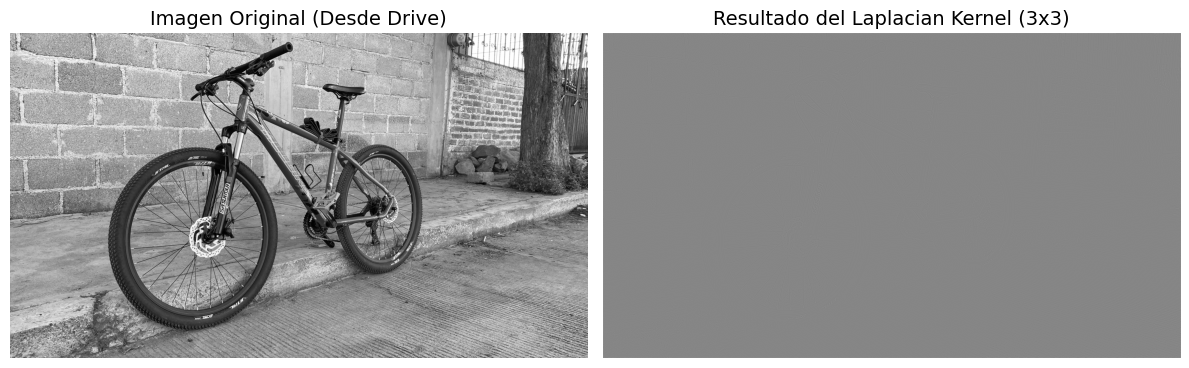

In [210]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(imagen_convolucionada_laplacian, cmap='gray')
axes[1].set_title("Resultado del Laplacian Kernel (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Scharr Kernels
#### Horizontal

In [203]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([   [ 3,   0,  -3],
                                [10,   0, -10],
                                [ 3,   0,  -3]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [204]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_charrHorizontal= F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [205]:
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
imagen_convolucionada_charrHorizontal = imagen_convolucionada_charrHorizontal.squeeze().numpy()

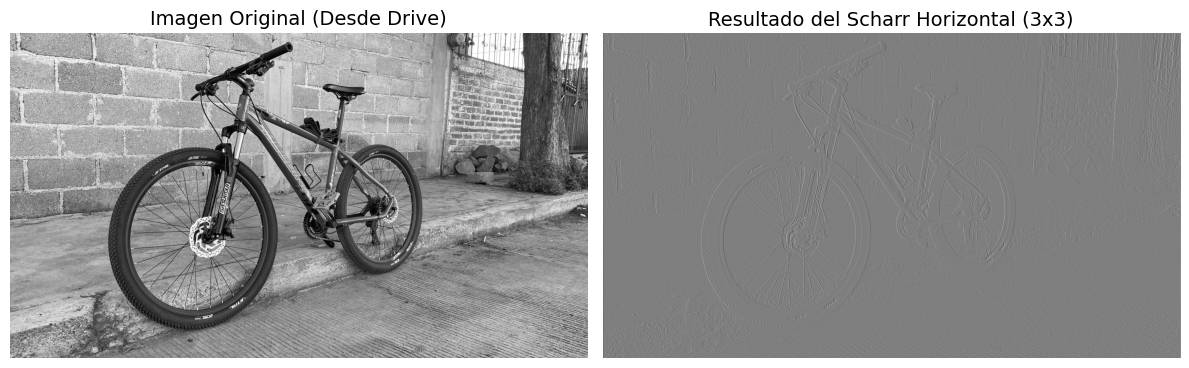

In [206]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(imagen_convolucionada_charrHorizontal, cmap='gray')
axes[1].set_title("Resultado del Scharr Horizontal (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### Scharr Vertical

In [198]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([   [ 3,   10,     3],
                                [ 0,   0,      0],
                                [-3,  -10,     -3]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor = torch.from_numpy(kernel_identidad)

# Ajustar las dimensiones del kernel para PyTorch: [Canales_Salida, Canales_Entrada, Alto_Kernel, Ancho_Kernel]
kernel_tensor = kernel_tensor.view(1, 1, 3, 3)

In [199]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_scharrvertical = F.conv2d(imagen_tensor, kernel_tensor, padding=1)

In [200]:
# Pasamos de [1, 1, H, W] a [H, W] retirando las dimensiones de tamaño 1.
imagen_convolucionada_scharrvertical = imagen_convolucionada_scharrvertical.squeeze().numpy()

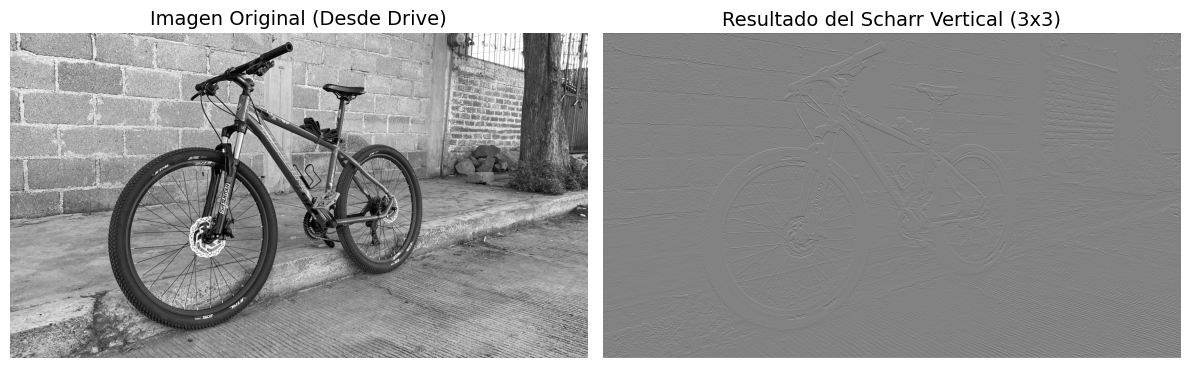

In [201]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(img_original_np, cmap='gray')
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(imagen_convolucionada_scharrvertical, cmap='gray')
axes[1].set_title("Resultado del Scharr Vertical (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Identidad RGB

In [226]:
## Cargando imagenes desde Drive
try:
    # 3. Cargar la imagen desde Drive y convertirla a escala de grises
    # Nota didáctica: Usamos escala de grises (1 solo canal) para facilitar la comprensión matemática de la convolución.
    imagen_rgb = Image.open(ruta_imagen_drive).convert('RGB')
    print("¡Imagen cargada correctamente desde Google Drive!")
except FileNotFoundError:
    print(f"Error: No se encontró ningún archivo en la ruta: {ruta_imagen_drive}")
    print("Por favor, verifica el nombre y la extensión del archivo en tu Google Drive.")


¡Imagen cargada correctamente desde Google Drive!


In [227]:
# Preprocesamiento: Convertir la imagen en un Tensor de PyTorch
# Transformamos la imagen a un tensor con valores en el rango [0, 1]
transformacion_rgb = transforms.ToTensor() 

imagen_tensor_rgb = transformacion_rgb(imagen_rgb) # Dimensiones resultantes: [Canales, Alto, Ancho] -> [1, H, W]

# PyTorch requiere que el lote (batch) tenga la forma: [Batch_Size, Canales, Alto, Ancho]
imagen_tensor_rgb = imagen_tensor_rgb.unsqueeze(0) # Añadimos la dimensión del lote -> [1, 1, H, W]


In [228]:
##Creando kernel de identidad con valores de 50
kernel_identidad = np.array([[0, 0, 0],
                             [0, 50, 0],
                            [0, 0, 0]
                           ], dtype=np.float32)

# Convertir el arreglo de NumPy a un Tensor de PyTorch
kernel_tensor_rgb = np.stack([kernel_identidad, kernel_identidad, kernel_identidad], axis=0)


kernels_tensor_rgb = torch.from_numpy( kernel_tensor_rgb )
kernels_tensor_rgb = kernels_tensor_rgb.view(3, 1, 3, 3)


In [229]:
# Usamos F.conv2d. Aplicamos 'padding=1' para mantener las dimensiones de la imagen de salida iguales a la de entrada.
imagen_convolucionada_rgb = F.conv2d(imagen_tensor_rgb, kernels_tensor_rgb, padding=1, groups=3)

In [230]:
imagen_original_rgb_np = imagen_tensor_rgb.squeeze(0).permute(1, 2, 0).numpy()


img_salida_np_rgb = imagen_convolucionada_rgb.squeeze(0).permute(1, 2, 0).numpy()
img_salida_np_rgb = np.clip(img_salida_np_rgb, 0, 1)


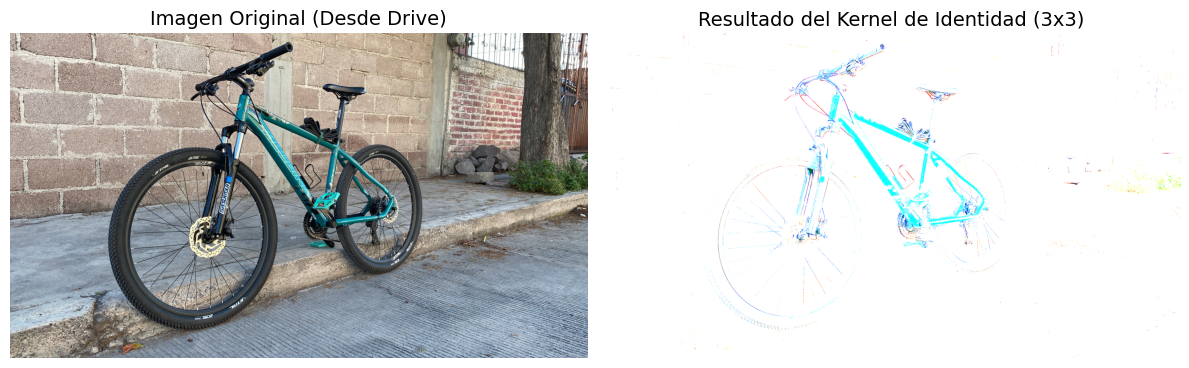

In [231]:
# Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Imagen Original
axes[0].imshow(imagen_original_rgb_np)
axes[0].set_title("Imagen Original (Desde Drive)", fontsize=14)
axes[0].axis('off')


# Subplot 2: Imagen Filtrada
axes[1].imshow(img_salida_np_rgb)
axes[1].set_title("Resultado del Kernel de Identidad (3x3)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()